# NSPPK HIV `nbits` Benchmark

This notebook downloads the MoleculeNet HIV dataset, converts molecules to `networkx` graphs with **discrete node and edge labels**, and studies how predictive performance changes as `nbits` varies.

The train/test split is created **once** and reused for every `nbits` value, so only the feature hashing dimension changes across runs.


In [18]:
from pathlib import Path
import pickle
import time
import urllib.request

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from statsmodels.nonparametric.smoothers_lowess import lowess

from nsppk import NSPPK

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

DATASET_URL = 'https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/HIV.csv'
CSV_PATH = DATA_DIR / 'HIV.csv'
GRAPH_CACHE_PATH = DATA_DIR / 'HIV_networkx_graphs.pkl'

NBITS_VALUES = list(range(6, 20))
RADIUS = 1
DISTANCE = 4
CONNECTOR = 1
LIMIT = 8000
BALANCE_DATASET = True
TRAIN_FRACTION = 0.7
TEST_SIZE = 1 - TRAIN_FRACTION
RANDOM_STATE = 42

RDLogger.DisableLog('rdApp.*')


## Download the HIV dataset


In [9]:
if not CSV_PATH.exists():
    urllib.request.urlretrieve(DATASET_URL, CSV_PATH)

df = pd.read_csv(CSV_PATH)
df.head()


,smiles,activity,HIV_active
0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,CI,0
1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,CI,0
2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,CI,0
3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,CI,0
4,O=S(=O)(O)CCS(=O)(=O)O,CI,0


## Convert molecules to `networkx` graphs

Node labels are discrete tuples built from atom-level categorical properties.
Edge labels are discrete tuples built from bond-level categorical properties.


In [10]:
def atom_to_discrete_label(atom):
    return (
        atom.GetAtomicNum(),
        atom.GetFormalCharge(),
        int(atom.GetChiralTag()),
        atom.GetTotalNumHs(),
        int(atom.GetHybridization()),
        int(atom.GetIsAromatic()),
    )


def bond_to_discrete_label(bond):
    return (
        str(bond.GetBondType()),
        int(bond.GetStereo()),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    )


def mol_to_nx_graph(mol):
    G = nx.Graph()

    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), label=atom_to_discrete_label(atom))

    for bond in mol.GetBonds():
        G.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            label=bond_to_discrete_label(bond),
        )

    return G


In [11]:
if GRAPH_CACHE_PATH.exists():
    with open(GRAPH_CACHE_PATH, 'rb') as f:
        cache = pickle.load(f)
    graphs = cache['graphs']
    labels = np.asarray(cache['labels'])
    smiles = cache['smiles']
else:
    graphs = []
    labels = []
    smiles = []

    for _, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['smiles'])
        if mol is None:
            continue
        graphs.append(mol_to_nx_graph(mol))
        labels.append(int(row['HIV_active']))
        smiles.append(row['smiles'])

    labels = np.asarray(labels)
    with open(GRAPH_CACHE_PATH, 'wb') as f:
        pickle.dump({'graphs': graphs, 'labels': labels, 'smiles': smiles}, f)

original_dataset_size = len(graphs)
if BALANCE_DATASET:
    pos_idx = np.flatnonzero(labels == 1)
    neg_idx = np.flatnonzero(labels == 0)
    rng = np.random.default_rng(RANDOM_STATE)

    if len(pos_idx) <= len(neg_idx):
        minority_idx, majority_idx = pos_idx, neg_idx
    else:
        minority_idx, majority_idx = neg_idx, pos_idx

    n_minority = len(minority_idx)
    balanced_size = 2 * n_minority
    target_size = balanced_size if LIMIT is None else min(LIMIT, len(labels))

    selected_minority = rng.choice(minority_idx, size=n_minority, replace=False)
    selected_majority_balanced = rng.choice(majority_idx, size=n_minority, replace=False)
    selected_idx = np.concatenate([selected_minority, selected_majority_balanced])

    if target_size > balanced_size:
        remaining_majority = np.setdiff1d(majority_idx, selected_majority_balanced, assume_unique=False)
        n_extra_majority = min(target_size - balanced_size, len(remaining_majority))
        extra_majority = rng.choice(remaining_majority, size=n_extra_majority, replace=False)
        selected_idx = np.concatenate([selected_idx, extra_majority])

    selected_idx = np.sort(selected_idx)
    graphs = [graphs[i] for i in selected_idx]
    labels = labels[selected_idx]
    smiles = [smiles[i] for i in selected_idx]

balanced_dataset_size = len(graphs)
if LIMIT is not None and not BALANCE_DATASET:
    graphs = graphs[:LIMIT]
    labels = labels[:LIMIT]
    smiles = smiles[:LIMIT]

print('original cached molecules:', original_dataset_size)
print('balance dataset:', BALANCE_DATASET)
print('molecules after balance:', balanced_dataset_size)
print('molecules after balance/limit:', len(graphs))
print(f'positive rate: {labels.mean():.3f}')
print('class counts:', {0: int((labels == 0).sum()), 1: int((labels == 1).sum())})
print('example node label:', next(iter(graphs[0].nodes(data=True)))[1]['label'])
print('example edge label:', next(iter(graphs[0].edges(data=True)))[2]['label'])


original cached molecules: 41120
balance dataset: True
molecules after balance: 8000
molecules after balance/limit: 8000
positive rate: 0.180
class counts: {0: 6557, 1: 1443}
example node label: (6, 0, 0, 3, 4, 0)
example edge label: ('SINGLE', 0, 0, 0)


## Fixed train/test split

If `BALANCE_DATASET = True`, we first build the largest balanced subset possible using all examples from the minority class and the same number from the majority class. If `LIMIT` is larger than that balanced size, we then add extra examples from the majority class until we reach `LIMIT` (or exhaust the dataset). We finally create one fixed **70% train / 30% test** split that is reused for every `nbits` value.


In [12]:
indices = np.arange(len(graphs))
train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)

train_graphs = [graphs[i] for i in train_idx]
test_graphs = [graphs[i] for i in test_idx]
y_train = labels[train_idx]
y_test = labels[test_idx]

print('limit:', LIMIT)
print('balance dataset:', BALANCE_DATASET)
print('train fraction:', TRAIN_FRACTION)
print('train size:', len(train_graphs))
print('test size:', len(test_graphs))
print(f'train positive rate: {y_train.mean():.2f}')
print(f'test positive rate: {y_test.mean():.2f}')


limit: 8000
balance dataset: True
train fraction: 0.7
train size: 5599
test size: 2401
train positive rate: 0.18
test positive rate: 0.18


## Sweep `nbits` on the same training and held-out test sets

We keep `(radius, distance, connector)` fixed and retrain the model for every `nbits` value.


In [13]:
results = []
n_runs = len(NBITS_VALUES)

print(
    f"{'run':>7} | {'nbits':>5} | {'features':>8} | {'nnz/graph':>9} | "
    f"{'memory (MB)':>11} | {'ROC-AUC':>7} | {'AP':>4} | {'vectorize':>10} | {'fit':>7}"
)
print('-' * 90)

for run_idx, nbits in enumerate(NBITS_VALUES, start=1):
    vectorizer = NSPPK(
        radius=RADIUS,
        distance=DISTANCE,
        connector=CONNECTOR,
        nbits=nbits,
        dense=False,
        parallel=True,
    )

    t0 = time.time()
    X_train = vectorizer.fit_transform(train_graphs)
    X_test = vectorizer.transform(test_graphs)
    vectorize_time = time.time() - t0

    clf = SGDClassifier(
        loss='hinge',
        penalty='l2',
        alpha=1e-4,
        class_weight='balanced',
        max_iter=2000,
        tol=1e-3,
        random_state=RANDOM_STATE,
    )
    t1 = time.time()
    clf.fit(X_train, y_train)
    fit_time = time.time() - t1

    train_memory_size_mb = (X_train.data.nbytes + X_train.indices.nbytes + X_train.indptr.nbytes) / (1024 ** 2)

    test_scores = clf.decision_function(X_test)
    test_roc_auc = roc_auc_score(y_test, test_scores)
    test_average_precision = average_precision_score(y_test, test_scores)
    result = {
        'nbits': nbits,
        'n_features': X_train.shape[1],
        'train_nnz_mean': float(X_train.getnnz(axis=1).mean()),
        'train_memory_size_mb': train_memory_size_mb,
        'test_roc_auc': test_roc_auc,
        'test_average_precision': test_average_precision,
        'vectorize_time_sec': vectorize_time,
        'fit_time_sec': fit_time,
    }
    results.append(result)
    print(
        f"[{run_idx:>2d}/{n_runs:<2d}] | "
        f"{nbits:>5d} | "
        f"{result['n_features']:>8d} | "
        f"{result['train_nnz_mean']:>9.2f} | "
        f"{train_memory_size_mb:>11.2f} | "
        f"{test_roc_auc:>7.2f} | "
        f"{test_average_precision:>4.2f} | "
        f"{vectorize_time:>9.2f}s | "
        f"{fit_time:>5.2f}s"
    )

results_df = pd.DataFrame(results)
results_df.round(2)


    run | nbits | features | nnz/graph | memory (MB) | ROC-AUC |   AP |  vectorize |     fit
------------------------------------------------------------------------------------------
[ 1/14] |     6 |       64 |     34.00 |        2.20 |    0.67 | 0.37 |     46.18s |  0.06s
[ 2/14] |     7 |      128 |     65.98 |        4.25 |    0.68 | 0.39 |     44.38s |  0.10s
[ 3/14] |     8 |      256 |    129.68 |        8.33 |    0.69 | 0.40 |     46.83s |  0.12s
[ 4/14] |     9 |      512 |    253.71 |       16.28 |    0.72 | 0.46 |     45.97s |  0.23s
[ 5/14] |    10 |     1024 |    472.26 |       30.28 |    0.77 | 0.48 |     48.75s |  0.49s
[ 6/14] |    11 |     2048 |    777.18 |       49.82 |    0.78 | 0.51 |     49.46s |  0.88s
[ 7/14] |    12 |     4096 |   1090.83 |       69.92 |    0.78 | 0.52 |     51.39s |  0.79s
[ 8/14] |    13 |     8192 |   1337.63 |       85.73 |    0.80 | 0.59 |     51.87s |  1.04s
[ 9/14] |    14 |    16384 |   1498.57 |       96.04 |    0.81 | 0.59 |     52.4

,nbits,n_features,train_nnz_mean,train_memory_size_mb,test_roc_auc,test_average_precision,vectorize_time_sec,fit_time_sec
0,6,64,34.00,2.20,0.67,0.37,46.18,0.06
1,7,128,65.98,4.25,0.68,0.39,44.38,0.10
2,8,256,129.68,8.33,0.69,0.40,46.83,0.12
3,9,512,253.71,16.28,0.72,0.46,45.97,0.23
4,10,1024,472.26,30.28,0.77,0.48,48.75,0.49
5,11,2048,777.18,49.82,0.78,0.51,49.46,0.88
6,12,4096,1090.83,69.92,0.78,0.52,51.39,0.79
7,13,8192,1337.63,85.73,0.80,0.59,51.87,1.04
8,14,16384,1498.57,96.04,0.81,0.59,52.40,1.32
9,15,32768,1590.56,101.94,0.82,0.64,50.98,1.56


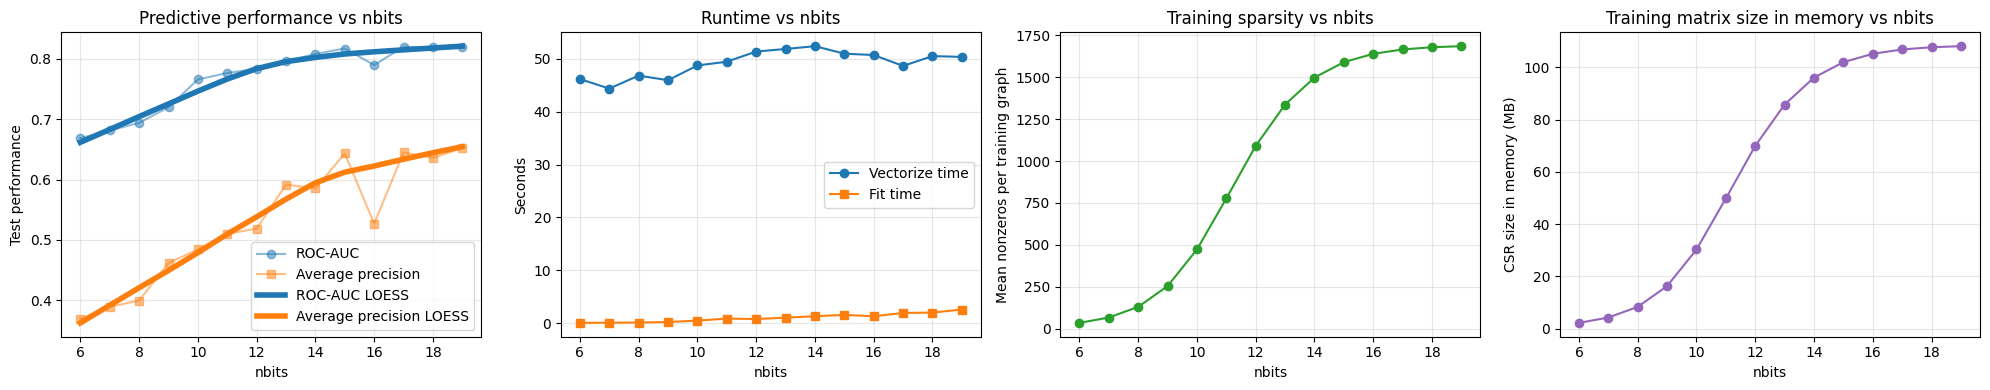

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

nbits_values = results_df['nbits'].to_numpy()
roc_auc_values = results_df['test_roc_auc'].to_numpy()
ap_values = results_df['test_average_precision'].to_numpy()
roc_auc_loess = lowess(roc_auc_values, nbits_values, frac=0.65, return_sorted=True)
ap_loess = lowess(ap_values, nbits_values, frac=0.65, return_sorted=True)

roc_auc_line, = axes[0].plot(nbits_values, roc_auc_values, marker='o', alpha=0.5, label='ROC-AUC')
ap_line, = axes[0].plot(nbits_values, ap_values, marker='s', alpha=0.5, label='Average precision')
axes[0].plot(roc_auc_loess[:, 0], roc_auc_loess[:, 1], linestyle='-', linewidth=4, alpha=1.0, color=roc_auc_line.get_color(), label='ROC-AUC LOESS')
axes[0].plot(ap_loess[:, 0], ap_loess[:, 1], linestyle='-', linewidth=4, alpha=1.0, color=ap_line.get_color(), label='Average precision LOESS')
axes[0].set_xlabel('nbits')
axes[0].set_ylabel('Test performance')
axes[0].set_title('Predictive performance vs nbits')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(results_df['nbits'], results_df['vectorize_time_sec'], marker='o', label='Vectorize time')
axes[1].plot(results_df['nbits'], results_df['fit_time_sec'], marker='s', label='Fit time')
axes[1].set_xlabel('nbits')
axes[1].set_ylabel('Seconds')
axes[1].set_title('Runtime vs nbits')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(results_df['nbits'], results_df['train_nnz_mean'], marker='o', color='tab:green')
axes[2].set_xlabel('nbits')
axes[2].set_ylabel('Mean nonzeros per training graph')
axes[2].set_title('Training sparsity vs nbits')
axes[2].grid(True, alpha=0.3)

axes[3].plot(results_df['nbits'], results_df['train_memory_size_mb'], marker='o', color='tab:purple')
axes[3].set_xlabel('nbits')
axes[3].set_ylabel('CSR size in memory (MB)')
axes[3].set_title('Training matrix size in memory vs nbits')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
